In [6]:
import pandas as pd
from pathlib import Path

from papers_lab.io import Storage, PaperTransform
from papers_lab import PaperAnalysis
from eda import Visualizer


In [7]:
root = Path("papers_test")
store = Storage()

researches = []
for sub in ("ieee", "acm"):
    d = root / sub
    if d.exists():
        researches += store.load_dir(d, pattern="*.pkl", recursive=True)

len(researches)

2

In [8]:
tx = PaperTransform()
df = tx.transform(researches, normalize_keywords=True)

pa = PaperAnalysis(df)

topkw = pa.top_keywords(20)
cooc = pa.cooccurrence_keywords(top_n=16)
kw_year = pa.keyword_trends(year_col="year", top_k=5)
auth_top = pa.author_frequency(top=3)
yr = pa.papers_per_year()
mo = pa.papers_per_month()
ym = pa.papers_per_year_month()
X = pa.bag_of_keywords()

In [9]:
df.head(2)

,title,date,abstract,DOI,source_url,authors,keywords,year,month,year_month,keywords_norm,n_keywords,n_authors,n_keywords_norm,n_abstract_words
0,The Use of UML Diagrams to Enhance Dynamic Fea...,20-21 November 2022,Unified Modeling Language (UML) is an efficien...,10.1109/3ICT56508.2022.9990768,https://ieeexplore.ieee.org/document/9990768/,"[Faisal Buzaid, Fawzi Albalooshi, Wael Elmedany]","[Technological innovation, Software maintenanc...",2022,11,2022-11,"[automated teller machines, case scenario, cla...",37,3,34,193
1,Mapping features to source code based on execu...,21-23 November 2021,One of the important activities in software ma...,10.1049/icp.2022.0316,https://ieeexplore.ieee.org/document/9770600/,"[F. Buzaid, M. Hammad]","[Source Code, Natural Language, Interesting Fe...",2021,11,2021-11,"[distance metrics, dynamic metrics, enterprise...",22,2,22,172


In [10]:
viz = Visualizer(cmap_name="plasma", figsize=(11, 6))

In [11]:
viz.stats_table(df["n_keywords"])

,count,mean,std,min,25%,50%,75%,max
n_keywords,9.0,29.444444,9.475114,11.0,25.0,31.0,37.0,42.0


In [12]:
viz.stats_table(df["n_authors"])

,count,mean,std,min,25%,50%,75%,max
n_authors,9.0,3.555556,1.013794,2.0,3.0,3.0,4.0,5.0


In [13]:
viz.stats_table(df["n_abstract_words"])

,count,mean,std,min,25%,50%,75%,max
n_abstract_words,9.0,219.333333,45.491757,172.0,183.0,207.0,237.0,310.0


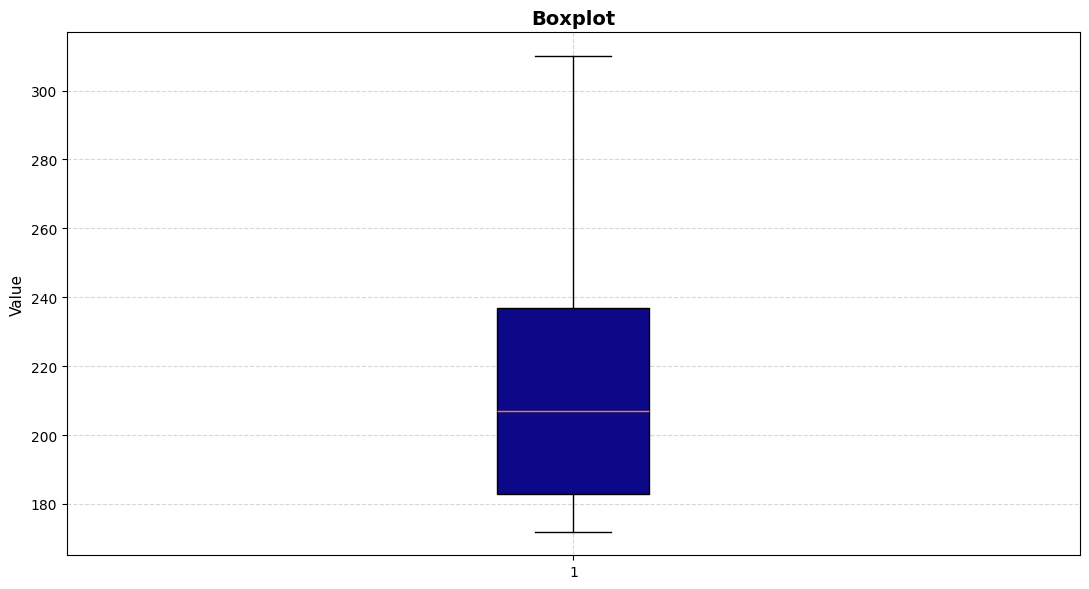

In [14]:
viz.boxplot(data=df["n_abstract_words"])

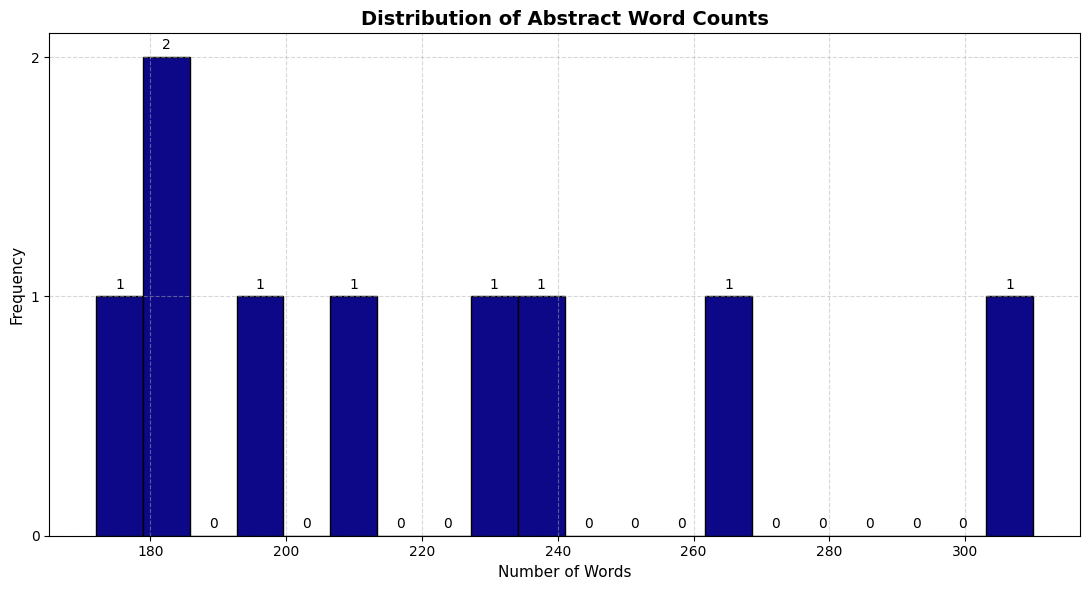

In [15]:
viz.histogram(df["n_abstract_words"], title="Distribution of Abstract Word Counts", xlabel="Number of Words")

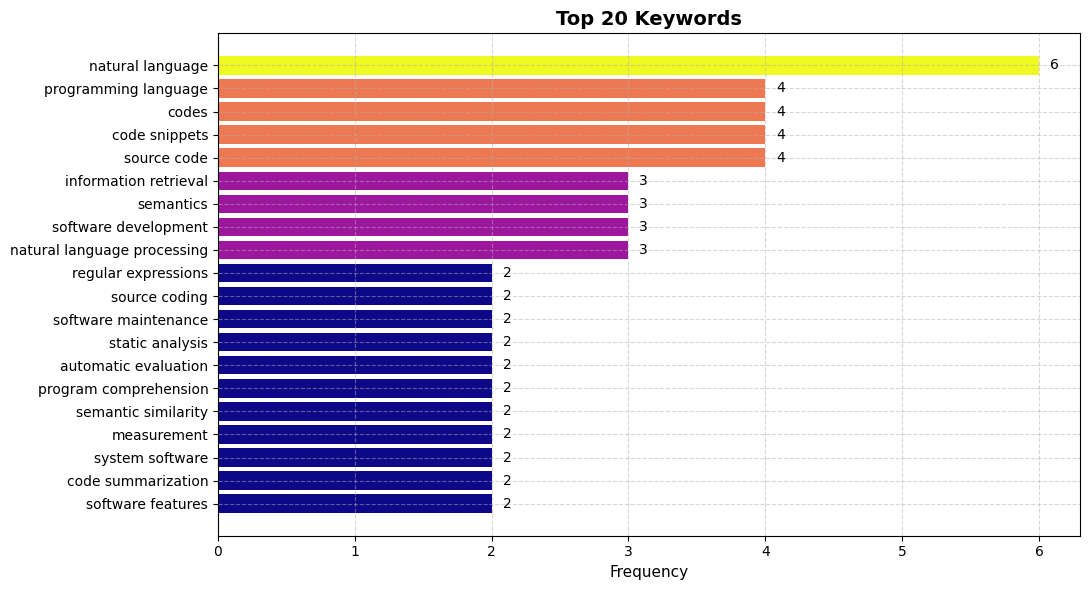

In [16]:
labels = topkw.index.tolist()
values = topkw.values.tolist()
viz.barh(labels, values, title=f"Top {len(values)} Keywords", xlabel="Frequency")


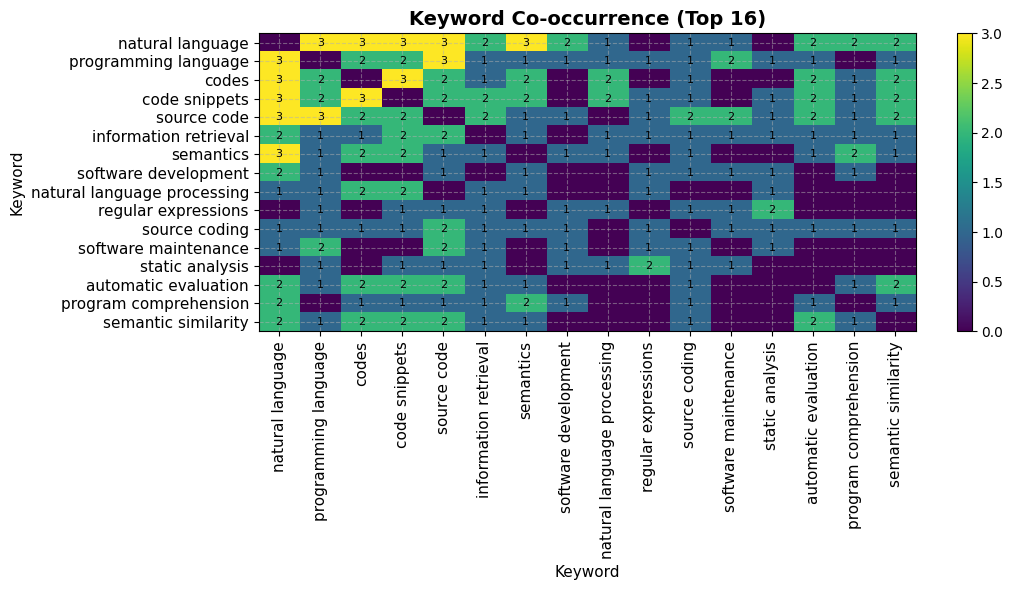

In [17]:
viz.heatmap(cooc, title="Keyword Co-occurrence (Top 16)", xlabel="Keyword", ylabel="Keyword", annotate=True)

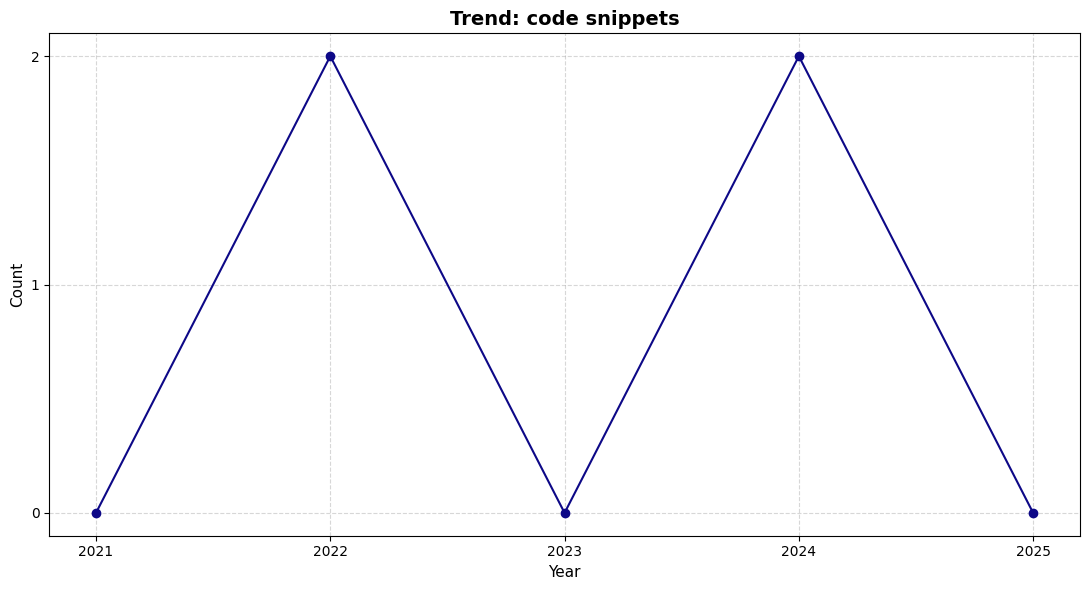

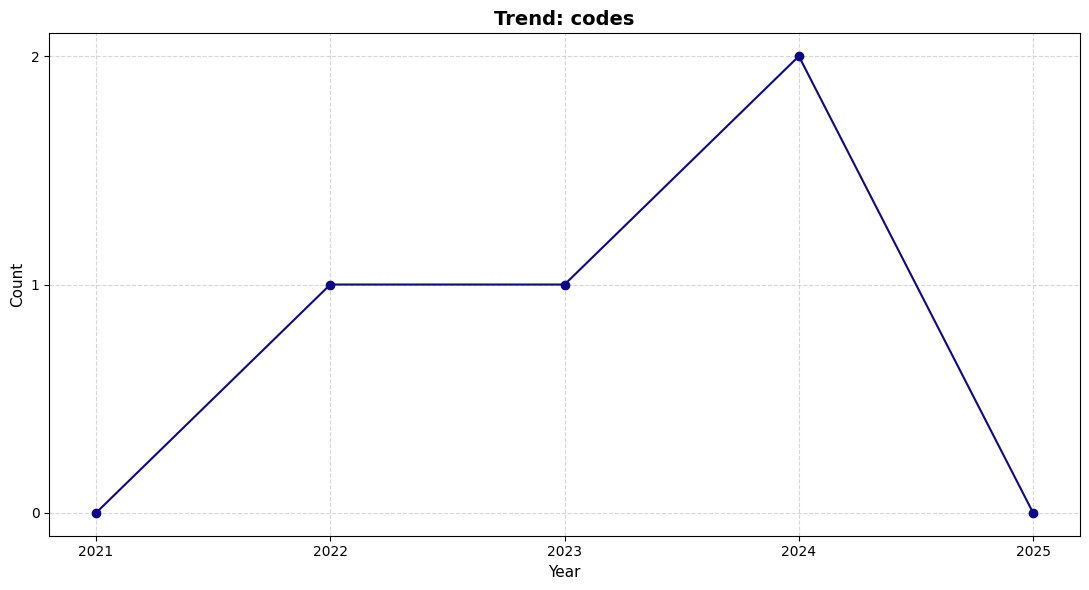

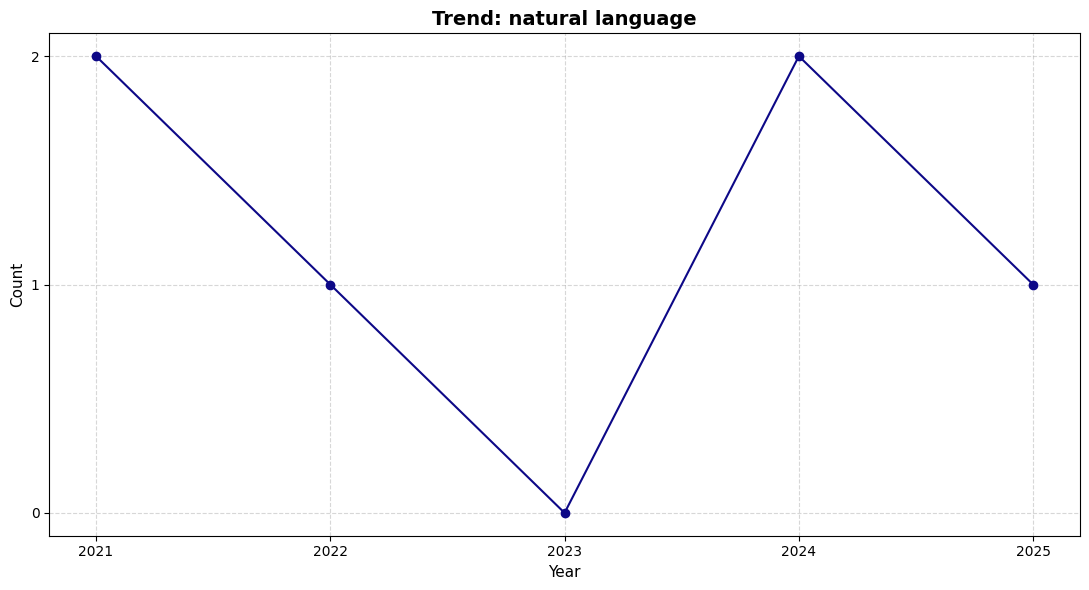

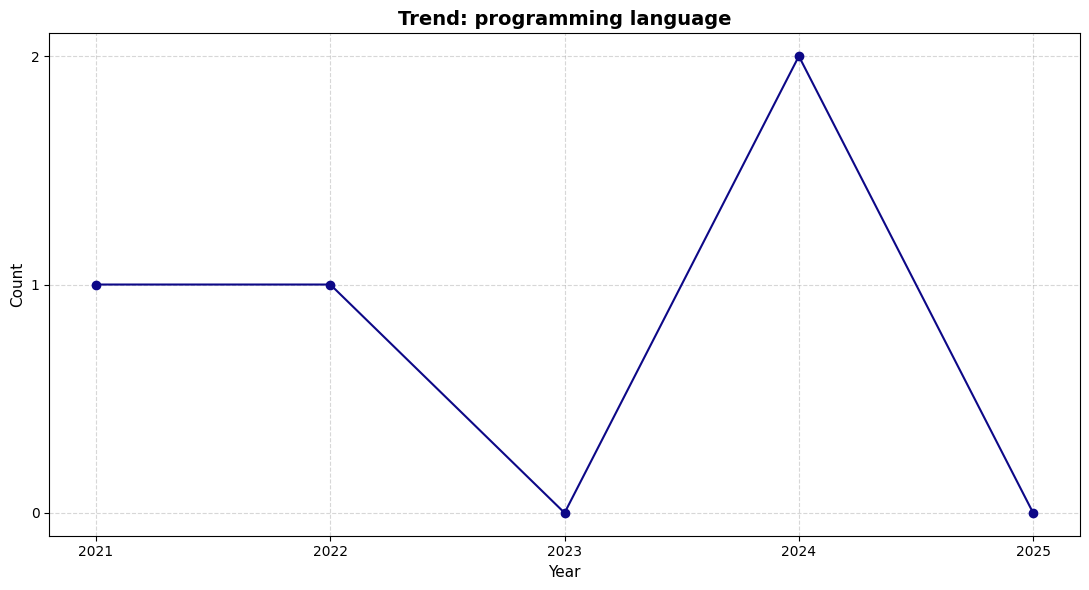

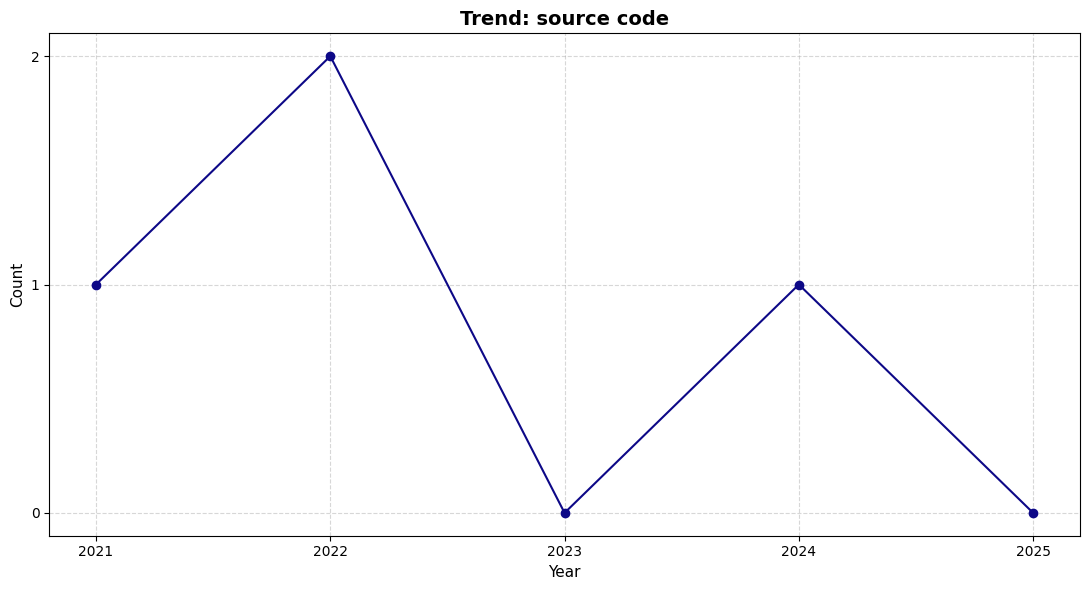

In [18]:
for kw in kw_year.columns:
    viz.line(kw_year.index, kw_year[kw].values, title=f"Trend: {kw}", xlabel="Year", ylabel="Count")

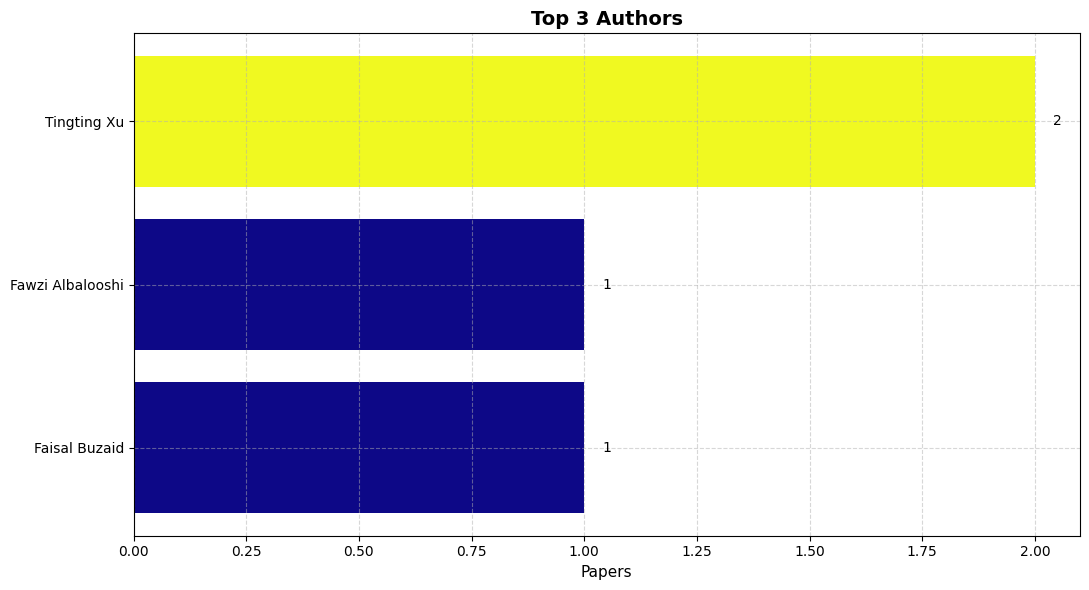

In [19]:
viz.barh(auth_top.index.tolist(), auth_top.values.tolist(),
         title=f"Top {len(auth_top)} Authors", xlabel="Papers")

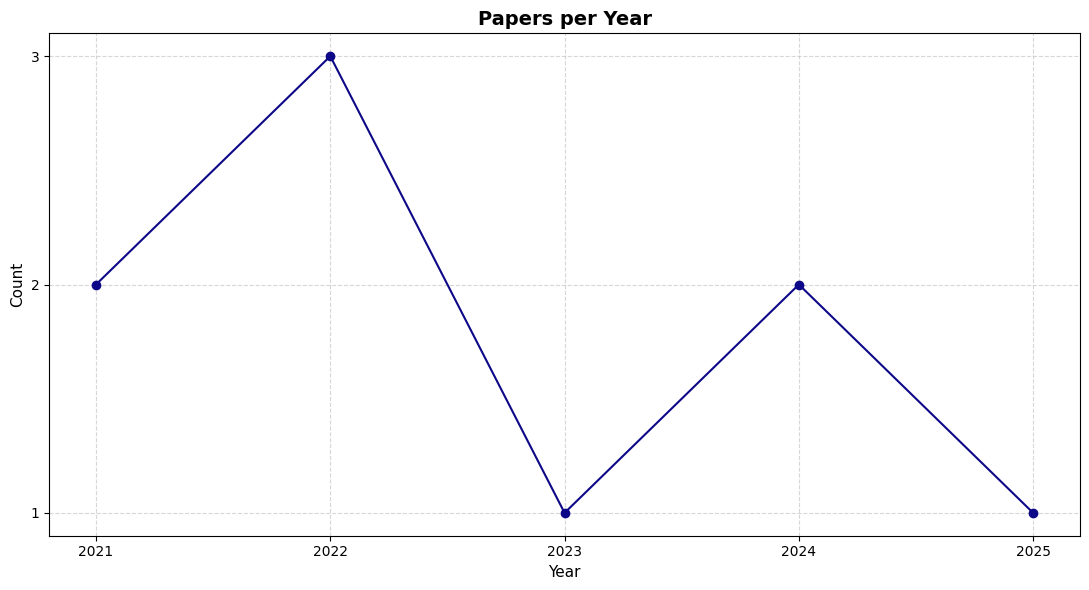

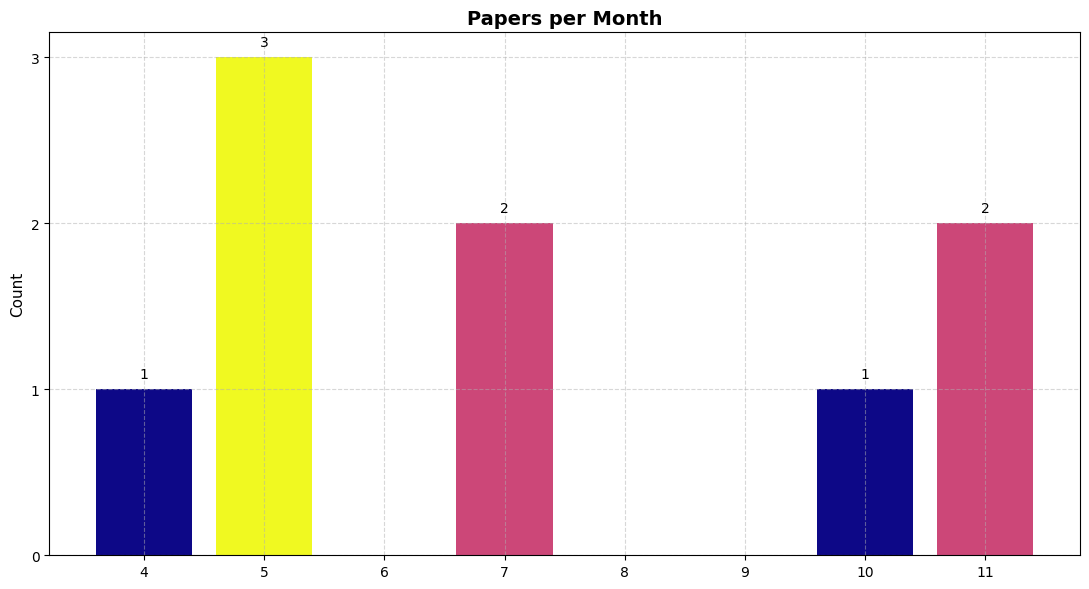

c:\Users\Isas_\OneDrive\Área de Trabalho\VSCODE\lisa-llm-reqs\eda\viz.py:324: FutureWarning: The provided callable <function sum at 0x00000284CA440720> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df = df.groupby("dt", as_index=False)["y"].agg(aggfunc)


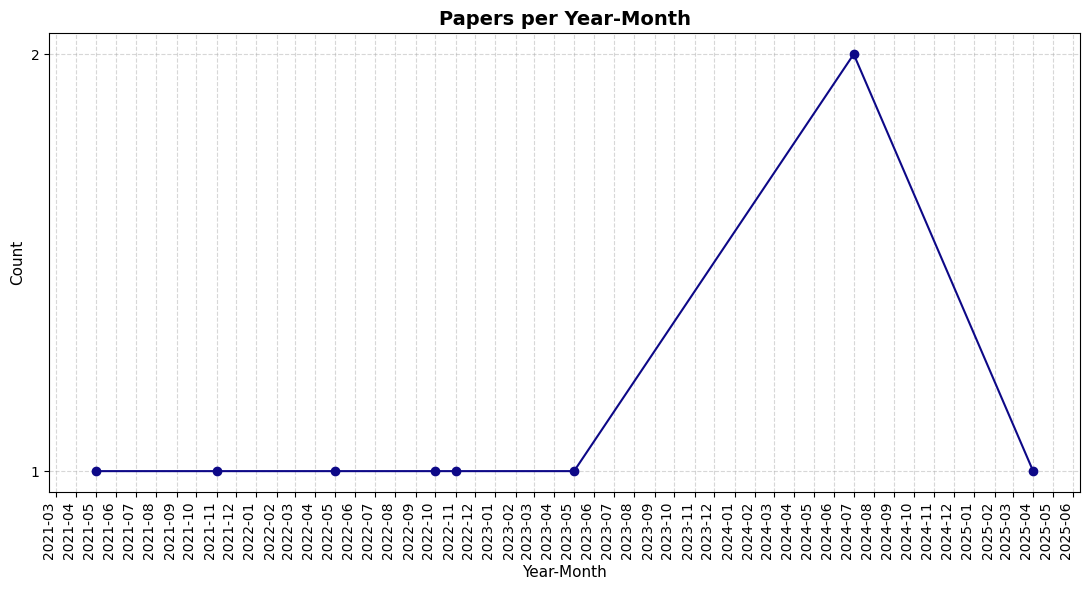

In [20]:
viz.line(yr.index.tolist(), yr.values.tolist(), title="Papers per Year", xlabel="Year", ylabel="Count")
viz.barv(mo.index.tolist(), mo.values.tolist(), title="Papers per Month", ylabel="Count")
viz.line(ym.index.tolist(), ym.values.tolist(), title="Papers per Year-Month", xlabel="Year-Month", ylabel="Count", rotation=90)

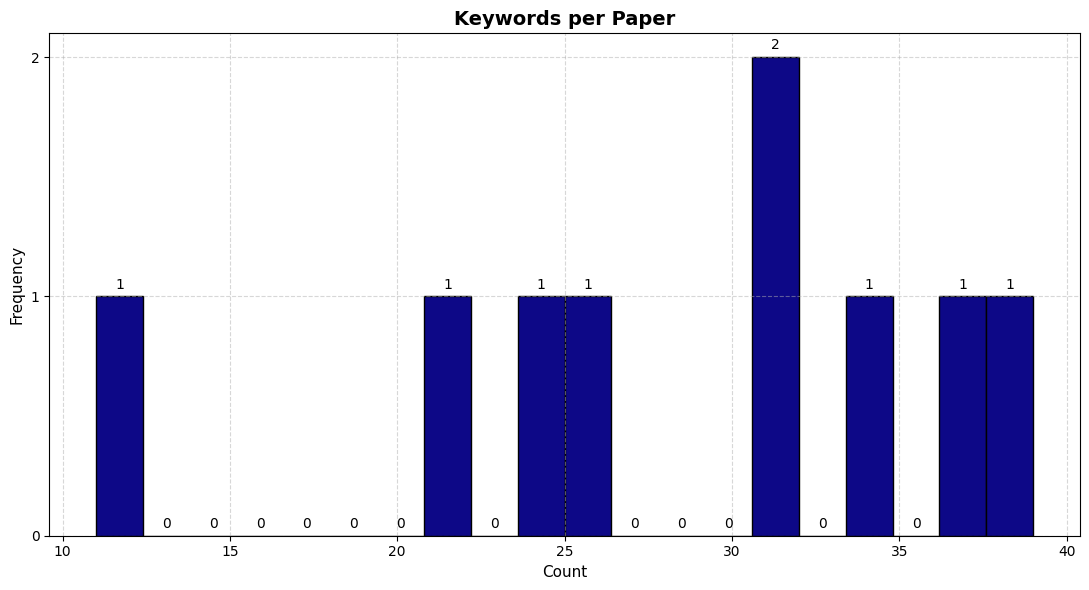

In [21]:
n_kw_per_paper = X.sum(axis=1).sort_values(ascending=False)
viz.histogram(n_kw_per_paper.values, title="Keywords per Paper", xlabel="Count")